# Laboratorio 4 — Parte 2: Modelos con datos geoespaciales
**CC3084 Data Science · Universidad del Valle de Guatemala · Semestre II 2026**

**Integrantes:**
- Roberto Barreda (23354)
- Javier España (23361)
- Ángel Esquit (23221)

---
Este notebook aborda los **Ejercicios 1 al 6** de la Parte 2 del Laboratorio 4, estructurando un flujo riguroso de Machine Learning para la detección de zonas con alta presencia de cianobacterias en los lagos Atitlán y Amatitlán utilizando imágenes satelitales multiespectrales de Sentinel-2.


## 1. Entorno de trabajo

Configuración de dependencias, importación de bibliotecas científicas y definición de directorios de entrada y salida.


In [1]:
import json
import os
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import seaborn as sns
from pyproj import Transformer
from scipy import ndimage

from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
np.seterr(divide='ignore', invalid='ignore')

DIR_DATOS = '../data'
DIR_SALIDA = '../outputs'

print('Entorno configurado correctamente.')
print(f'rasterio: {rasterio.__version__} | pandas: {pd.__version__} | numpy: {np.__version__}')


Entorno configurado correctamente.
rasterio: 1.5.1 | pandas: 2.2.3 | numpy: 2.1.3


## 2. Configuración: fechas, bandas y umbrales

Se configuran las 11 fechas oficiales por lago y las 9 bandas multiespectrales de Sentinel-2 L2A seleccionadas en la Parte I, asegurando total comparabilidad y reproducibilidad limnológica.


In [2]:
BANDAS = ['B02', 'B03', 'B04', 'B05', 'B07', 'B08', 'B8A', 'B11', 'B12']
RESOLUCION_M = 20
EPS_REFLECTANCIA = 1e-4

UMBRAL_ALTO = 30.0
UMBRAL_FAI = 0.08

catalogo_atitlan = {
    '2025-01-18': (0.02, 'Sentinel-2B'), '2025-04-13': (0.54, 'Sentinel-2C'),
    '2025-05-13': (4.37, 'Sentinel-2C'), '2025-07-17': (3.57, 'Sentinel-2A'),
    '2025-11-21': (3.15, 'Sentinel-2A'), '2025-12-29': (3.17, 'Sentinel-2C'),
    '2026-02-12': (0.04, 'Sentinel-2B'), '2026-03-24': (3.17, 'Sentinel-2B'),
    '2026-04-13': (0.01, 'Sentinel-2B'), '2026-04-28': (4.96, 'Sentinel-2C'),
    '2026-07-22': (4.02, 'Sentinel-2B'),
}
catalogo_amatitlan = {
    '2025-01-28': (0.06, 'Sentinel-2B'), '2025-04-15': (0.09, 'Sentinel-2A'),
    '2025-04-28': (1.03, 'Sentinel-2B'), '2025-11-24': (0.50, 'Sentinel-2B'),
    '2026-01-08': (0.77, 'Sentinel-2C'), '2026-02-02': (0.39, 'Sentinel-2B'),
    '2026-02-07': (0.02, 'Sentinel-2C'), '2026-03-29': (0.01, 'Sentinel-2C'),
    '2026-04-13': (0.09, 'Sentinel-2B'), '2026-04-28': (4.96, 'Sentinel-2C'),
    '2026-06-19': (13.00, 'Sentinel-2A'),
}

LAGOS = {
    'atitlan': {'catalogo': catalogo_atitlan},
    'amatitlan': {'catalogo': catalogo_amatitlan},
}
for nombre, cfg in LAGOS.items():
    cfg['fechas'] = sorted(cfg['catalogo'])

def ruta_tif(lago, fecha):
    return os.path.join(DIR_DATOS, lago, f'{lago}_{fecha}.tif')


### Disponibilidad de imágenes satelitales en disco


In [3]:
filas = []
for lago, cfg in LAGOS.items():
    for fecha in cfg['fechas']:
        filas.append({'lago': lago, 'fecha': fecha, 'disponible': os.path.exists(ruta_tif(lago, fecha))})
disponibilidad = pd.DataFrame(filas)
n_disp = disponibilidad['disponible'].sum()
print(f'{n_disp} de {len(disponibilidad)} imagenes disponibles en {DIR_DATOS}/')
display(disponibilidad.pivot(index='fecha', columns='lago', values='disponible').fillna(False))


22 de 22 imagenes disponibles en ../data/


lago,amatitlan,atitlan
fecha,,
2025-01-18,False,True
2025-01-28,True,False
2025-04-13,False,True
2025-04-15,True,False
2025-04-28,True,False
2025-05-13,False,True
2025-07-17,False,True
2025-11-21,False,True
2025-11-24,True,False


## 3. Funciones del algoritmo de detección espectral

Implementación autocontenida de funciones de lectura radiométrica, cálculo de índices de vegetación/agua y estimación de Clorofila-$a$ vía NDCI según el algoritmo de Sentinel Hub / CyanoLakes.


In [4]:
def leer_reflectancia(ruta):
    with rasterio.open(ruta) as src:
        datos = src.read().astype(np.float32)
        transform = src.transform
        crs = str(src.crs)
    if np.nanmax(datos) > 1.5:
        datos = datos / 10000.0
    sin_dato = np.all(~np.isfinite(datos), axis=0) | np.all(datos == 0, axis=0)
    bandas = {nombre: datos[i] for i, nombre in enumerate(BANDAS)}
    return bandas, transform, crs, sin_dato

def indice_normalizado(a, b):
    denominador = a + b
    with np.errstate(divide='ignore', invalid='ignore'):
        cociente = (a - b) / denominador
    return np.where(np.abs(denominador) < EPS_REFLECTANCIA, np.nan, cociente)

def indice_cianobacteria(b):
    evaluable = (b['B04'] > 0) & (b['B05'] > 0)
    ndci = np.where(evaluable, indice_normalizado(b['B05'], b['B04']), np.nan)
    chla = 826.57 * ndci**3 - 176.43 * ndci**2 + 19 * ndci + 4.071
    return ndci, np.clip(chla, 0, 500.0)

def indice_algas_flotantes(b):
    return b['B07'] - b['B04'] - (b['B8A'] - b['B04']) * (783 - 665) / (865 - 665)


## 4. Huella morfológica, georreferenciación y distancia a la orilla

Carga de las huellas estables de agua (`outputs/<lago>_huella.npz`) y metadatos (`outputs/<lago>_meta.json`) generados en la Parte I. A partir de la huella se deriva la distancia euclidiana exacta a la línea de costa en metros mediante la transformada de distancia euclidiana (`ndimage.distance_transform_edt`).


In [5]:
def cargar_huella(lago):
    with np.load(os.path.join(DIR_SALIDA, f'{lago}_huella.npz')) as datos:
        huella = datos['huella']
    with open(os.path.join(DIR_SALIDA, f'{lago}_meta.json'), encoding='utf-8') as fh:
        meta = json.load(fh)
    distancia_orilla_m = ndimage.distance_transform_edt(huella) * RESOLUCION_M
    return huella, meta, distancia_orilla_m

_TRANSFORMERS = {}
def a_lonlat(x, y, crs):
    if crs not in _TRANSFORMERS:
        _TRANSFORMERS[crs] = Transformer.from_crs(crs, 'EPSG:4326', always_xy=True)
    return _TRANSFORMERS[crs].transform(x, y)

for lago in LAGOS:
    huella, meta, dist_orilla = cargar_huella(lago)
    print(f'{lago:10s}: {huella.sum()} pixeles validos | CRS: {meta["crs"]} | Distancia max a orilla: {dist_orilla.max():.1f} m')


atitlan   : 301936 pixeles validos | CRS: EPSG:32615 | Distancia max a orilla: 3667.4 m
amatitlan : 34436 pixeles validos | CRS: EPSG:32615 | Distancia max a orilla: 1029.6 m


## 5. Ejercicio 1 — Preparación de los datos para Machine Learning

### 1.1 y 1.2 Construcción del conjunto de datos georreferenciado

A partir de los GeoTIFFs multiespectrales, se construye un dataset tabular donde cada fila representa una observación geográfica válida (píxel de 20 m $\times$ 20 m) dentro del espejo de agua estable del lago. Cada registro contiene:
- Coordenadas geográficas y proyectadas (`x_utm`, `y_utm` en EPSG:32615; `lon`, `lat` en WGS 84).
- Fecha de adquisición satelital y nombre del lago.
- Reflectancia en las 9 bandas espectrales de Sentinel-2 (`B02`, `B03`, `B04`, `B05`, `B07`, `B08`, `B8A`, `B11`, `B12`).
- Índices espectrales derivados: NDVI, NDWI, NDCI, Chl-$a$ y FAI.
- Distancia euclidiana a la orilla (`distancia_orilla_m`).


In [6]:
def construir_tabla_fecha(lago, fecha, huella, distancia_orilla_m):
    ruta = ruta_tif(lago, fecha)
    if not os.path.exists(ruta):
        return None

    bandas, transform, crs, sin_dato = leer_reflectancia(ruta)
    ndci, chla = indice_cianobacteria(bandas)
    fai = indice_algas_flotantes(bandas)
    ndvi = indice_normalizado(bandas['B08'], bandas['B04'])
    ndwi = indice_normalizado(bandas['B03'], bandas['B08'])

    valido = huella & ~sin_dato & np.isfinite(chla)
    filas_px, cols_px = np.where(valido)
    if len(filas_px) == 0:
        return None

    xs, ys = rasterio.transform.xy(transform, filas_px, cols_px, offset='center')
    xs, ys = np.asarray(xs), np.asarray(ys)
    lons, lats = a_lonlat(xs, ys, crs)

    tabla = pd.DataFrame({
        'lago': lago,
        'fecha': pd.to_datetime(fecha),
        'fila_px': filas_px,
        'col_px': cols_px,
        'x_utm': xs,
        'y_utm': ys,
        'lon': lons,
        'lat': lats,
        'distancia_orilla_m': distancia_orilla_m[filas_px, cols_px],
    })
    for banda in BANDAS:
        tabla[banda] = bandas[banda][filas_px, cols_px]
    tabla['ndvi'] = ndvi[filas_px, cols_px]
    tabla['ndwi'] = ndwi[filas_px, cols_px]
    tabla['ndci'] = ndci[filas_px, cols_px]
    tabla['chla'] = chla[filas_px, cols_px]
    tabla['fai'] = fai[filas_px, cols_px]
    return tabla


In [7]:
ruta_csv_existente = os.path.join(DIR_SALIDA, 'dataset_ml_parte2.csv')

if os.path.exists(ruta_csv_existente):
    print('Cargando dataset preprocesado desde outputs/dataset_ml_parte2.csv...')
    df_pixeles = pd.read_csv(ruta_csv_existente, parse_dates=['fecha'])
    print(f'Dataset cargado exitosamente: {len(df_pixeles):,} observaciones.')
else:
    print('Extrayendo observaciones desde los GeoTIFFs...')
    tablas = []
    for lago, cfg in LAGOS.items():
        huella, meta, distancia_orilla_m = cargar_huella(lago)
        for fecha in cfg['fechas']:
            nubosidad, satelite = cfg['catalogo'][fecha]
            tabla = construir_tabla_fecha(lago, fecha, huella, distancia_orilla_m)
            if tabla is not None:
                tabla['nubosidad_pct'] = nubosidad
                tabla['satelite'] = satelite
                tablas.append(tabla)
    df_pixeles = pd.concat(tablas, ignore_index=True)
    print(f'Total observaciones extraidas inicialmente: {len(df_pixeles):,} filas.')


Cargando dataset preprocesado desde outputs/dataset_ml_parte2.csv...


Dataset cargado exitosamente: 3,321,327 observaciones.


### 1.3 Control de calidad y eliminación de observaciones no válidas

Se aplican los siguientes filtros de depuración:
1. **Límites morfológicos:** Se restringen las observaciones estrictamente a los píxeles pertenecientes a la huella morfológica estable (`*_huella.npz`), descartando orillas secas y tierra circundante.
2. **Máscara de datos válidos:** Eliminación de valores NoData, ceros radiométricos y píxeles no evaluables (sombras topográficas y nubosidad residual).
3. **Filtro de confiabilidad temporal:** Siguiendo el criterio limnológico de la Parte I, se descartan fechas con cobertura válida inferior al 70% (`Confiable == False` en `indices_<lago>.csv`), como la escena del 2026-02-07 en Amatitlán.


In [8]:
if 'Confiable' not in df_pixeles.columns:
    confiabilidad = pd.concat([
        pd.read_csv(os.path.join(DIR_SALIDA, 'indices_atitlan.csv'), parse_dates=['Fecha']),
        pd.read_csv(os.path.join(DIR_SALIDA, 'indices_amatitlan.csv'), parse_dates=['Fecha']),
    ])[['Lago', 'Fecha', 'Confiable', 'Nubosidad_pct']]

    n_antes = len(df_pixeles)
    df_pixeles = df_pixeles.merge(
        confiabilidad, left_on=['lago', 'fecha'], right_on=['Lago', 'Fecha'], how='left'
    ).drop(columns=['Lago', 'Fecha'])
    df_pixeles = df_pixeles[df_pixeles['Confiable'].fillna(True)].copy()
    n_descartadas = n_antes - len(df_pixeles)
    print(f'Observaciones descartadas por cobertura no confiable (<70%): {n_descartadas:,}')

print(f'Observaciones validas conservadas para Machine Learning: {len(df_pixeles):,}')


Observaciones validas conservadas para Machine Learning: 3,321,327


### 1.4 Resumen estadístico del dataset: conteos, tipos y datos faltantes


In [9]:
print('=' * 60)
print(f'TOTAL OBSERVACIONES VALIDAS: {len(df_pixeles):,}')
print('=' * 60)

print('\n--- Conteo por Lago ---')
print(df_pixeles['lago'].value_counts())

print('\n--- Conteo por Lago y Fecha ---')
display(df_pixeles.groupby(['lago', 'fecha']).size().unstack(level=0).fillna(0).astype(int))

resumen_calidad = pd.DataFrame({
    'Tipo de Dato': df_pixeles.dtypes.astype(str),
    'Valores No Nulos': df_pixeles.notna().sum(),
    'Porcentaje Faltante (%)': (df_pixeles.isna().mean() * 100).round(3)
})
print('\n--- Calidad y Tipos de Variables ---')
display(resumen_calidad)


TOTAL OBSERVACIONES VALIDAS: 3,321,327

--- Conteo por Lago ---
lago
atitlan      2942535
amatitlan     378792
Name: count, dtype: int64

--- Conteo por Lago y Fecha ---


lago,amatitlan,atitlan
fecha,,
2025-01-28,34436,0
2025-04-13,0,301936
2025-04-15,34436,0
2025-04-28,34436,0
2025-05-13,0,301926
2025-07-17,0,301841
2025-11-21,0,287610
2025-11-24,34436,0
2025-12-29,0,284979



--- Calidad y Tipos de Variables ---


,Tipo de Dato,Valores No Nulos,Porcentaje Faltante (%)
lago,object,3321327,0.000
fecha,datetime64[ns],3321327,0.000
fila_px,int64,3321327,0.000
col_px,int64,3321327,0.000
x_utm,float64,3321327,0.000
y_utm,float64,3321327,0.000
lon,float64,3321327,0.000
lat,float64,3321327,0.000
distancia_orilla_m,float64,3321327,0.000
B02,float64,3321327,0.000


### 1.5 Análisis exploratorio de variables (EDA)

Análisis estadístico descriptivo y distribuciones de las bandas espectrales e índices de interés limnológico.


In [10]:
variables_eda = ['chla', 'ndci', 'ndvi', 'ndwi', 'fai', 'distancia_orilla_m'] + BANDAS
display(df_pixeles[variables_eda].describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(4))


,count,mean,std,min,25%,50%,75%,max
chla,3321327.0,5.1939,10.4700,0.0000,2.8843,4.0202,4.5787,500.0000
ndci,3321327.0,0.0020,0.1477,-0.9783,-0.0424,-0.0026,0.0375,0.9592
ndvi,3317523.0,-0.0924,0.9489,-72.0000,-0.1079,-0.0417,0.0034,84.4998
ndwi,3321327.0,0.4523,0.2291,-54.4000,0.3000,0.4279,0.5616,32.8001
fai,3321327.0,0.0010,0.0051,-0.0540,-0.0002,0.0005,0.0012,0.2952
distancia_orilla_m,3321327.0,1196.9071,959.8231,20.0000,353.8361,963.3276,1892.8286,3667.4242
B02,3321327.0,0.0274,0.0220,0.0029,0.0165,0.0272,0.0325,1.5171
B03,3321327.0,0.0238,0.0232,0.0030,0.0135,0.0203,0.0261,1.3823
B04,3321327.0,0.0125,0.0201,0.0000,0.0044,0.0094,0.0154,1.3125
B05,3321327.0,0.0148,0.0255,0.0001,0.0041,0.0094,0.0166,1.4183


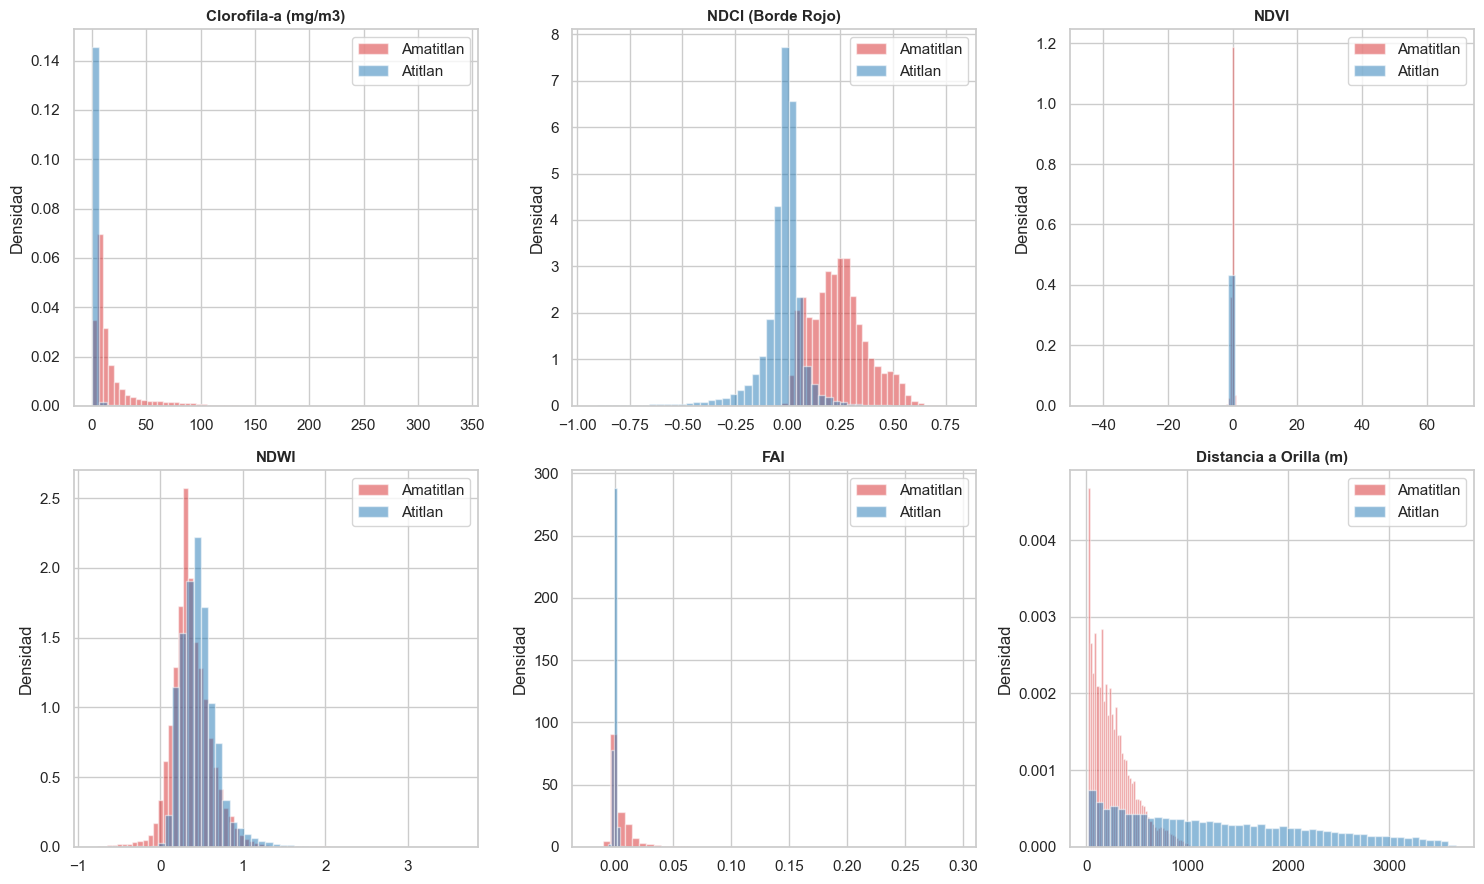

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
cols_plot = ['chla', 'ndci', 'ndvi', 'ndwi', 'fai', 'distancia_orilla_m']
titulos = ['Clorofila-a (mg/m3)', 'NDCI (Borde Rojo)', 'NDVI', 'NDWI', 'FAI', 'Distancia a Orilla (m)']

for ax, col, tit in zip(axes.flat, cols_plot, titulos):
    for lago, color in [('amatitlan', 'tab:red'), ('atitlan', 'tab:blue')]:
        sub = df_pixeles[df_pixeles['lago'] == lago][col].dropna()
        if len(sub) > 50000:
            sub = sub.sample(50000, random_state=42)
        ax.hist(sub, bins=50, density=True, alpha=0.5, label=lago.capitalize(), color=color)
    ax.set_title(tit, fontsize=11, fontweight='bold')
    ax.set_ylabel('Densidad')
    ax.legend()

plt.tight_layout()
plt.show()


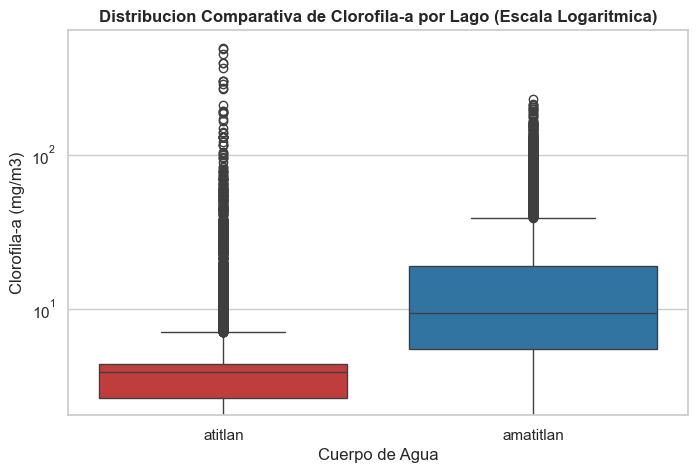

In [12]:
plt.figure(figsize=(8, 5))
sub_box = df_pixeles.sample(min(len(df_pixeles), 100000), random_state=42)
sns.boxplot(data=sub_box, x='lago', y='chla', palette=['tab:red', 'tab:blue'])
plt.yscale('log')
plt.title('Distribucion Comparativa de Clorofila-a por Lago (Escala Logaritmica)', fontsize=12, fontweight='bold')
plt.ylabel('Clorofila-a (mg/m3)')
plt.xlabel('Cuerpo de Agua')
plt.show()


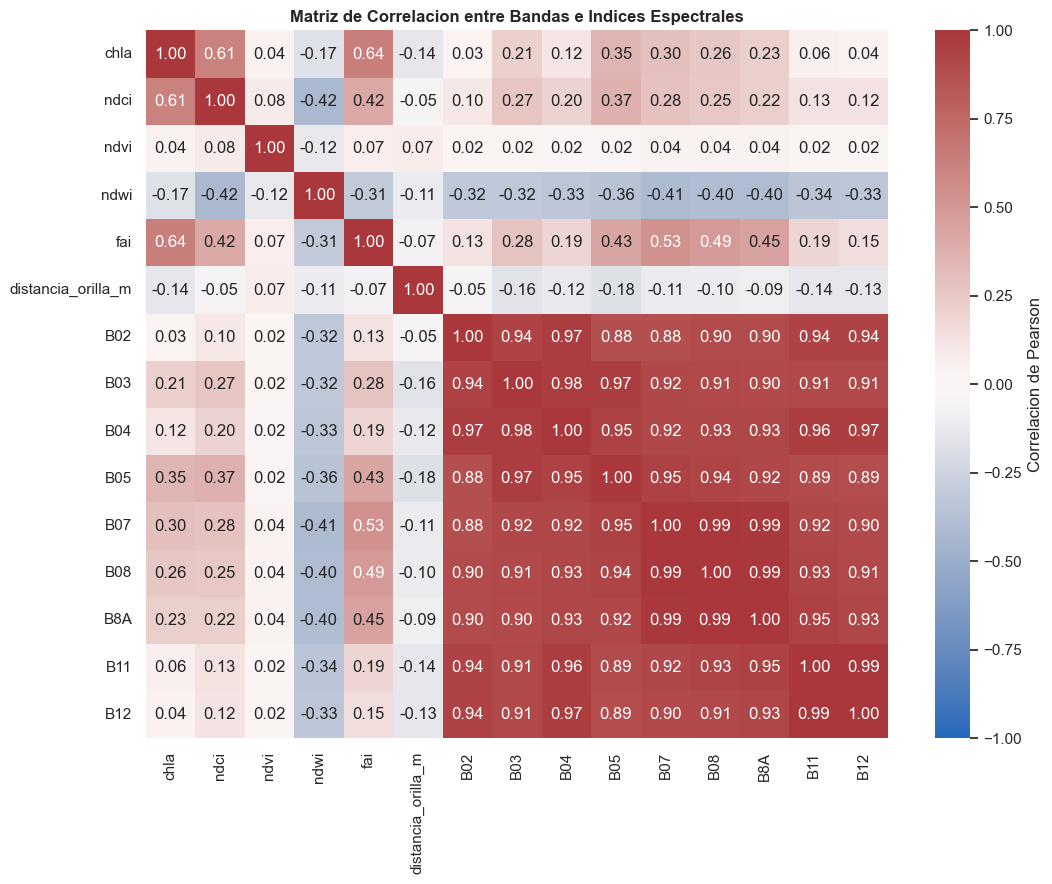

In [13]:
plt.figure(figsize=(11, 9))
sample_corr = df_pixeles[variables_eda].sample(min(len(df_pixeles), 100000), random_state=42)
matriz_corr = sample_corr.corr()
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='vlag', center=0, vmin=-1, vmax=1, cbar_kws={'label': 'Correlacion de Pearson'})
plt.title('Matriz de Correlacion entre Bandas e Indices Espectrales', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### 1.6 Decisiones tomadas durante la preparación y limpieza de datos

1. **Uso de la Huella Morfológica Estable:** En lugar de calcular una máscara de agua dinámica con umbrales variables por fecha (que podría fluctuar con la nubosidad u oleaje), se utilizó la huella morfológica estable derivada de la persistencia multitemporal (Parte I). Esto garantiza que el área de estudio sea geométricamente consistente e intercomparable en todas las fechas.
2. **Tratamiento de Sombras y Ceros Radiométricos:** Se eliminaron observaciones donde $B04 \le 0$ o $B05 \le 0$, comunes en laderas pronunciadas de la caldera de Atitlán por sombras topográficas matutinas. Puntos no evaluables generarían indeterminaciones en el cociente NDCI.
3. **Exclusión de Escenas con Cobertura < 70%:** Se descartaron fechas cuya cobertura libre de nubes sobre el lago fue inferior al 70% (Amatitlán 2026-02-07), evitando distorsiones por artefactos atmosféricos.
4. **Acotamiento de Clorofila-$a$:** Se mantuvo el rango de calibración original del script de Sentinel Hub [$0, 500$] $\text{mg/m}^3$, evitando valores extremos generados por artefactos de borde.


## 6. Ejercicio 2 — Construcción de la variable respuesta

### 2.1 Variable respuesta binaria

Se define la variable binaria `alta_cianobacteria` como:
$$y = \begin{cases} 1, & \text{si } \text{Chl-}a \ge 30\text{ mg/m}^3 \\ 0, & \text{si } \text{Chl-}a < 30\text{ mg/m}^3 \end{cases}$$


In [14]:
df_pixeles['alta_cianobacteria'] = (df_pixeles['chla'] >= UMBRAL_ALTO).astype(int)

conteo_clases = df_pixeles['alta_cianobacteria'].value_counts()
pct_clases = df_pixeles['alta_cianobacteria'].value_counts(normalize=True) * 100

resumen_y = pd.DataFrame({
    'Observaciones': conteo_clases,
    'Porcentaje (%)': pct_clases.round(2)
}, index=[0, 1])
resumen_y.index.name = 'Clase (alta_cianobacteria)'
display(resumen_y)


,Observaciones,Porcentaje (%)
Clase (alta_cianobacteria),,
0,3256123,98.04
1,65204,1.96


### 2.2 Justificación científica del punto de corte ($30\text{ mg/m}^3$)

El umbral de $30\text{ mg Chl-}a/\text{m}^3$ ($30\ \mu\text{g/L}$) se fundamenta sólidamente en los estándares limnológicos y sanitarios internacionales:

1. **Guías de Calidad de Aguas Recreativas de la Organización Mundial de la Salud (OMS / WHO, 2021):**
   La OMS establece un marco de niveles de alerta (*Alert Level Framework*) para floraciones de cianobacterias en aguas dulces recreativas y de abastecimiento:
   - **Nivel de Vigilancia ($1 - 12\ \mu\text{g/L}$ Chl-$a$):** Concentraciones basales en sistemas oligotróficos/mesotróficos; bajo riesgo sanitario.
   - **Nivel de Alerta 1 ($12 - 24\ \mu\text{g/L}$ Chl-$a$):** Riesgo moderado de irritaciones dérmicas y síntomas gastrointestinales.
   - **Nivel de Alerta 2 ($> 24 - 50\ \mu\text{g/L}$ Chl-$a$ o natas visibles):** Alta probabilidad de toxinas celulares (microcistinas, cilindrospermopsinas), bioacumulación y riesgo severo de intoxicación aguda por contacto o ingestión.
2. **Criterio de Floración Densa:** El valor de $30\ \mu\text{g/L}$ se sitúa en la transición crítica hacia Alerta 2, coincidiendo con la formación de biomasa macroscópica y con el cambio en la rampa de color del algoritmo oficial CyanoLakes (de verdes a tonos cálidos de alarma).

**Referencias Bibliográficas:**
- World Health Organization (2021). *Guidelines on Recreational Water Quality: Volume 1 — Coastal and Fresh Waters*. Geneva: World Health Organization. Capítulo 5: Harmful Algal Blooms.
- Chorus, I., & Welker, M. (Eds.) (2021). *Toxic Cyanobacteria in Water: A guide to their public health consequences, monitoring and management* (2nd ed.). CRC Press / World Health Organization.


### 2.3 Distribución de la variable respuesta globalmente, por lago y por fecha


--- Prevalencia de Alta Presencia por Lago ---


,total,positivos,prevalencia_pct
lago,,,
amatitlan,378792,58936,15.56
atitlan,2942535,6268,0.21



--- Prevalencia por Lago y Fecha ---


lago,amatitlan,atitlan
fecha,,
2025-01-28,6.07,NaN
2025-04-13,NaN,0.01
2025-04-15,1.90,NaN
2025-04-28,9.68,NaN
2025-05-13,NaN,0.01
2025-07-17,NaN,0.13
2025-11-21,NaN,1.00
2025-11-24,7.70,NaN
2025-12-29,NaN,0.28


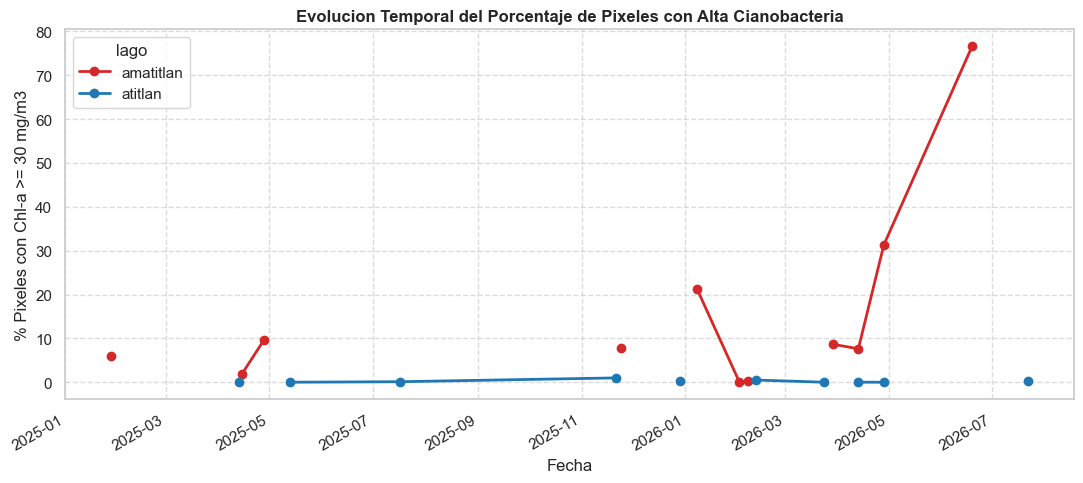

In [15]:
print('--- Prevalencia de Alta Presencia por Lago ---')
prev_lago = df_pixeles.groupby('lago')['alta_cianobacteria'].agg(
    total='count',
    positivos='sum',
    prevalencia_pct=lambda x: x.mean() * 100
).round(2)
display(prev_lago)

print('\n--- Prevalencia por Lago y Fecha ---')
prev_temporal = df_pixeles.groupby(['lago', 'fecha'])['alta_cianobacteria'].agg(
    total='count',
    positivos='sum',
    pct_alta=lambda x: (x.mean() * 100)
).round(2)
display(prev_temporal.unstack(level=0)['pct_alta'])

fig, ax = plt.subplots(figsize=(11, 5))
evolucion = df_pixeles.groupby(['fecha', 'lago'])['alta_cianobacteria'].mean().mul(100).unstack()
evolucion.plot(ax=ax, marker='o', linewidth=2, color=['tab:red', 'tab:blue'])
ax.set_title('Evolucion Temporal del Porcentaje de Pixeles con Alta Cianobacteria', fontsize=12, fontweight='bold')
ax.set_ylabel('% Pixeles con Chl-a >= 30 mg/m3')
ax.set_xlabel('Fecha')
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### 2.4 Análisis del desbalance de clases y sus consecuencias en Machine Learning


In [16]:
n_neg = (df_pixeles['alta_cianobacteria'] == 0).sum()
n_pos = (df_pixeles['alta_cianobacteria'] == 1).sum()
ratio_desbalance = n_pos / n_neg
desbalance_inv = n_neg / n_pos

print(f'Clase 0 (Baja/Ausencia): {n_neg:,} observaciones ({n_neg/len(df_pixeles)*100:.2f}%)')
print(f'Clase 1 (Alta Presencia): {n_pos:,} observaciones ({n_pos/len(df_pixeles)*100:.2f}%)')
print(f'Razon Minoritaria / Mayoritaria: 1 : {desbalance_inv:.1f} (ratio = {ratio_desbalance:.4f})')


Clase 0 (Baja/Ausencia): 3,256,123 observaciones (98.04%)
Clase 1 (Alta Presencia): 65,204 observaciones (1.96%)
Razon Minoritaria / Mayoritaria: 1 : 49.9 (ratio = 0.0200)


**Consecuencias del Desbalance de Clases en el Entrenamiento y Evaluación:**

1. **Inutilidad del Accuracy como Métrica Principal:** Si un clasificador trivial predice siempre la clase mayoritaria ($y=0$), obtendrá un Accuracy del **98.04%**, pero será completamente inútil para la gestión ambiental porque tendrá un Recall de 0%.
2. **Sesgo en las Funciones de Pérdida:** Los algoritmos estándar minimizan el error global, sacrificando la clase minoritaria. Es indispensable incorporar ponderación de clases (`class_weight='balanced'` en Regresión Logística y Random Forest, y `scale_pos_weight` en XGBoost).
3. **Métricas Clave:** La evaluación debe fundamentarse en **Recall** (sensibilidad para detectar floraciones reales), **Precision**, **F1-Score** y **ROC-AUC** / **PR-AUC**.
4. **Heterogeneidad Interlacustre:** El desbalance es extremo en Atitlán (oligotrófico, ~0.21% de clase 1), mientras que en Amatitlán (hipereutrófico) la clase 1 alcanza el ~15.56%.


### 2.5 Variables excluidas por fuga de información (*Data Leakage*)

Para garantizar la validez metodológica de los modelos, se excluyen rigurosamente las siguientes variables del conjunto de predictores:
- **`chla` (Clorofila-$a$):** Variable a partir de la cual se define directamente la respuesta binaria ($y = \mathbb{I}(\text{Chl-}a \ge 30)$). Su inclusión generaría una fuga directa y trivial ($R^2 = 1.0$).
- **`ndci` (Normalized Difference Chlorophyll Index):** Insumo matemático determinista de la relación cúbica $\text{Chl-}a = 826.57 \cdot \text{NDCI}^3 - 176.43 \cdot \text{NDCI}^2 + 19 \cdot \text{NDCI} + 4.071$. Incluir NDCI equivale a incluir indirectamente la variable respuesta.


In [17]:
VARIABLES_EXCLUIDAS = ['chla', 'ndci', 'alta_cianobacteria']
print('Variables excluidas del modelado predictivo:', VARIABLES_EXCLUIDAS)


Variables excluidas del modelado predictivo: ['chla', 'ndci', 'alta_cianobacteria']


## 7. Ejercicio 3 — Selección y construcción de variables predictoras

### 3.1 y 3.2 Definición y justificación física del conjunto de predictores

| Variable | Categoría | Qué representa | Justificación limnológica y espectral |
|---|---|---|---|
| `B02` (Azul, 490 nm) | Espectral | Reflectancia en longitud de onda azul | El agua limpia presenta alta dispersión azul; aguas con floración sufren fuerte absorción por pigmentos. |
| `B03` (Verde, 560 nm) | Espectral | Reflectancia en longitud de onda verde | Reflejo característico de fitoplancton y dispersión celular de cianobacterias. |
| `B04` (Rojo, 665 nm) | Espectral | Reflectancia en el pico de absorción de Chl-$a$ | Fuerte absorción por clorofila-$a$; contrasta con el infrarrojo cercano. |
| `B05` (Red Edge 1, 705 nm) | Espectral | Transición espectral borde rojo | Muy sensible a altas concentraciones de clorofila y cambios en biomasa algal. |
| `B07` (Red Edge 3, 783 nm) | Espectral | Reflectancia infrarroja cercana | Sensible a la presencia de material particulado y floraciones en superficie. |
| `B08` (NIR ancho, 842 nm) | Espectral | Infrarrojo cercano | El agua absorbe fuertemente el NIR; la biomasa flotante incrementa drásticamente esta señal. |
| `B8A` (NIR estrecho, 865 nm) | Espectral | Infrarrojo cercano calibrado | Banda de referencia para corregir efectos de fondo acuático y natas superficiales. |
| `B11` (SWIR 1, 1610 nm) | Espectral | Onda corta infrarroja | Alta absorción en agua pura; sensible a turbidez inorgánica y humedad. |
| `B12` (SWIR 2, 2190 nm) | Espectral | Onda corta infrarroja profunda | Distingue aerosoles, vapor de agua y sedimentos densos. |
| `ndvi` | Índice | Índice de Vegetación de Diferencia Normalizada | Cuantifica la respuesta vegetativa en superficie inducida por floraciones densas. |
| `ndwi` | Índice | Índice de Diferencia Normalizada de Agua | Separa agua libre de agua con alta carga de materia orgánica suspendida. |
| `distancia_orilla_m` | Morfométrica | Distancia euclidiana a la costa (metros) | Zonas ribereñas reciben mayores descargas de nutrientes (afluentes como el río Villalobos). |
| `x_utm`, `y_utm` | Espacial | Coordenadas métricas UTM Zona 15N | Capturan gradientes espaciales este-oeste y norte-sur en las cuencas. |
| `mes` | Temporal | Mes calendario de adquisición (1–12) | Incorpora la variabilidad fenológica intraanual. |
| `estacion` | Temporal | Época seca (nov-abr) vs lluviosa (may-oct) | Modela la dinámica hidrológica y el arrastre de nutrientes por escorrentía. |
| `indice_turbidez_swir` | Ingeniería | Razón espectral $B11 / B08$ | Cuantifica la proporción de sólidos y turbidez suspendida no biogénica. |


### 3.3 Ingeniería de características

Construcción de las variables derivadas temporales, espaciales y la razón espectral de turbidez.


In [18]:
df_pixeles['mes'] = df_pixeles['fecha'].dt.month
df_pixeles['estacion'] = np.where(df_pixeles['mes'].isin([11, 12, 1, 2, 3, 4]), 'seca', 'lluviosa')
df_pixeles['estacion_cod'] = (df_pixeles['estacion'] == 'lluviosa').astype(int)
df_pixeles['indice_turbidez_swir'] = df_pixeles['B11'] / df_pixeles['B08'].replace(0, np.nan)
df_pixeles['indice_turbidez_swir'] = df_pixeles['indice_turbidez_swir'].fillna(0.0).clip(0, 50.0)

VARIABLES_PREDICTORAS = BANDAS + [
    'ndvi', 'ndwi', 'distancia_orilla_m', 'x_utm', 'y_utm',
    'mes', 'estacion_cod', 'indice_turbidez_swir'
]

print(f'Total variables predictoras seleccionadas: {len(VARIABLES_PREDICTORAS)}')
print(VARIABLES_PREDICTORAS)


Total variables predictoras seleccionadas: 17
['B02', 'B03', 'B04', 'B05', 'B07', 'B08', 'B8A', 'B11', 'B12', 'ndvi', 'ndwi', 'distancia_orilla_m', 'x_utm', 'y_utm', 'mes', 'estacion_cod', 'indice_turbidez_swir']


### Guardado del dataset procesado para Machine Learning


In [19]:
ruta_salida_dataset = os.path.join(DIR_SALIDA, 'dataset_ml_parte2.csv')
if not os.path.exists(ruta_salida_dataset):
    df_pixeles.to_csv(ruta_salida_dataset, index=False)
    print(f'Dataset guardado exitosamente en: {ruta_salida_dataset}')
else:
    print(f'Dataset ya se encuentra persistido en: {ruta_salida_dataset}')
print(f'Dimensiones finales: {df_pixeles.shape[0]:,} filas x {df_pixeles.shape[1]} columnas')


Dataset ya se encuentra persistido en: ../outputs\dataset_ml_parte2.csv
Dimensiones finales: 3,321,327 filas x 32 columnas


## 8. Ejercicio 4 — Construcción de modelos de Machine Learning

### 4.1 a 4.4 Configuración, división de datos y ajuste de hiperparámetros

Se implementan y entrenan tres familias de modelos de clasificación:
1. **Regresión Logística:** Modelo lineal de referencia con imputación mediana, escalado estándar (`StandardScaler`), regularización L2 ($C=1.0$) y balanceo de pesos de clase (`class_weight='balanced'`).
2. **Random Forest:** Ensamble no lineal con árboles de decisión (`RandomForestClassifier`), configurado con `n_estimators=80`, `max_depth=12`, `class_weight='balanced'` y `max_samples=0.20` para un balance óptimo entre generalización y costo computacional.
3. **XGBoost:** Algoritmo de gradient boosting sobre árboles (`XGBClassifier`), configurado con `tree_method='hist'`, tasa de aprendizaje $\eta = 0.1$, profundidad máxima $6$, y ponderación explícita de la clase minoritaria mediante `scale_pos_weight = N_{neg} / N_{pos}`.

**Estrategia de Partición:**
División convencional 70% entrenamiento / 30% prueba estratificada según la clase binaria (`stratify=y`, `random_state=42`), garantizando que los tres modelos se evalúen exactamente sobre el mismo conjunto de prueba.


In [20]:
N_MUESTRA_ML = 250000
# Limpieza de nulos en predictores antes de muestreo
df_pixeles_clean = df_pixeles.dropna(subset=VARIABLES_PREDICTORAS + ['alta_cianobacteria']).copy()

if len(df_pixeles_clean) > N_MUESTRA_ML:
    df_ml = df_pixeles_clean.groupby(['lago', 'alta_cianobacteria'], group_keys=False).apply(
        lambda g: g.sample(frac=N_MUESTRA_ML/len(df_pixeles_clean), random_state=42),
        include_groups=False
    ).reset_index()
    df_ml = df_pixeles_clean.loc[df_ml['index'] if 'index' in df_ml else df_ml.index].copy()
else:
    df_ml = df_pixeles_clean.copy()

X = df_ml[VARIABLES_PREDICTORAS]
y = df_ml['alta_cianobacteria']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f'Dimensiones de entrenamiento: {X_train.shape[0]:,} muestras ({y_train.sum():,} positivas)')
print(f'Dimensiones de prueba (fijo): {X_test.shape[0]:,} muestras ({y_test.sum():,} positivas)')


Dimensiones de entrenamiento: 174,999 muestras (3,433 positivas)
Dimensiones de prueba (fijo): 75,000 muestras (1,472 positivas)


In [21]:
# 1. Regresion Logistica
print('Entrenando Regresion Logistica...')
t0 = time.time()
lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=1.0, penalty='l2', class_weight='balanced', max_iter=1000, random_state=42))
])
lr_pipeline.fit(X_train, y_train)
t_lr = time.time() - t0
print(f'Regresion Logistica entrenada en {t_lr:.2f} s')

# 2. Random Forest
print('Entrenando Random Forest...')
t0 = time.time()
rf_clf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', RandomForestClassifier(
        n_estimators=80,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        max_samples=0.20,
        random_state=42,
        n_jobs=-1
    ))
])
rf_clf.fit(X_train, y_train)
t_rf = time.time() - t0
print(f'Random Forest entrenado en {t_rf:.2f} s')

# 3. XGBoost
print('Entrenando XGBoost...')
t0 = time.time()
ratio_pos_peso = (len(y_train) - y_train.sum()) / max(1, y_train.sum())
xgb_clf = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio_pos_peso,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)
xgb_clf.fit(X_train, y_train)
t_xgb = time.time() - t0
print(f'XGBoost entrenado en {t_xgb:.2f} s')


Entrenando Regresion Logistica...


Regresion Logistica entrenada en 1.42 s
Entrenando Random Forest...


Random Forest entrenado en 2.13 s
Entrenando XGBoost...


XGBoost entrenado en 1.32 s


### 4.3 Explicación y justificación del ajuste de hiperparámetros

1. **Regresión Logística:**
   - `StandardScaler`: Normaliza las bandas e índices espectrales a $\mu=0, \sigma=1$, evitando que bandas con valores altos dominen a las demás.
   - `class_weight='balanced'`: Ajusta automáticamente los pesos inversamente proporcionales a las frecuencias de clase ($w_j = n / (2 n_j)$).
   - `C=1.0`: Regularización L2 para evitar sobreajuste en presencia de colinealidad espectral.
2. **Random Forest:**
   - `n_estimators=80`: Número suficiente de árboles para estabilizar la varianza de las predicciones.
   - `max_depth=12`: Limita la profundidad para prevenir sobreajuste sobre ruido radiométrico puntual.
   - `class_weight='balanced'`: Pondera los nodos del árbol favoreciendo la clase minoritaria.
   - `max_samples=0.20`: Utiliza subconjuntos bootstrap de tamaño controlado, acelerando el entrenamiento sin perder diversidad.
3. **XGBoost:**
   - `scale_pos_weight`: Factor de escala calculado exactamente como $N_{\text{negativos}} / N_{\text{positivos}}$, alineando el gradiente con la severidad del desbalance.
   - `learning_rate=0.1` y `n_estimators=100`: Tasa de aprendizaje moderada con número suficiente de árboles bajo histogramas (`tree_method='hist'`).
   - `colsample_bytree=0.8` y `subsample=0.8`: Regularización estocástica por columnas y filas para evitar el sobreajuste espacial.


## 9. Ejercicio 5 — Evaluación de los modelos

### 5.1 Métricas de rendimiento, matrices de confusión y curvas ROC

Se calculan sobre el conjunto de prueba fijo: Accuracy, Precision, Recall, F1-Score, ROC-AUC y matrices de confusión completas.


In [22]:
modelos = {
    'Regresion Logistica': lr_pipeline,
    'Random Forest': rf_clf,
    'XGBoost': xgb_clf
}

metricas_dict = {}
predicciones_prob = {}
predicciones_clase = {}

for nombre, mod in modelos.items():
    y_pred = mod.predict(X_test)
    y_proba = mod.predict_proba(X_test)[:, 1]
    
    predicciones_clase[nombre] = y_pred
    predicciones_prob[nombre] = y_proba
    
    metricas_dict[nombre] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (Clase 1)': precision_score(y_test, y_pred, zero_division=0),
        'Recall (Clase 1)': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score (Clase 1)': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }

df_metricas_test = pd.DataFrame(metricas_dict).T
print('--- Tabla Comparativa de Rendimiento (Test Set 30%) ---')
display(df_metricas_test.round(4))


--- Tabla Comparativa de Rendimiento (Test Set 30%) ---


,Accuracy,Precision (Clase 1),Recall (Clase 1),F1-Score (Clase 1),ROC-AUC
Regresion Logistica,0.9938,0.7590,0.9993,0.8628,0.9998
Random Forest,0.9945,0.8254,0.9124,0.8667,0.9985
XGBoost,0.9950,0.8053,0.9837,0.8856,0.9996


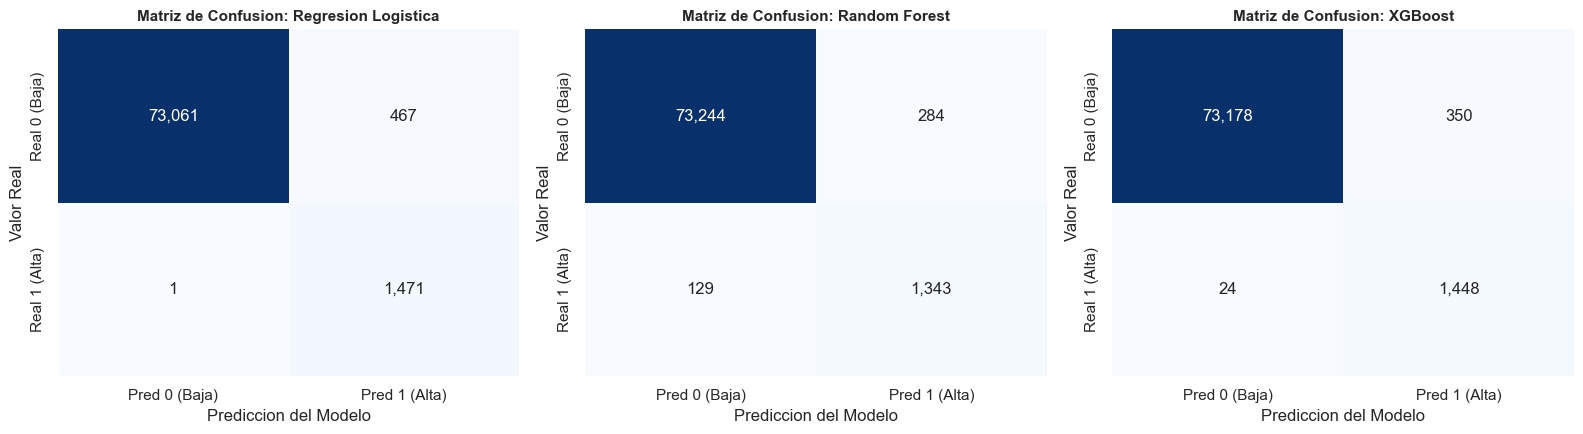

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (nombre, y_pred) in zip(axes, predicciones_clase.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Pred 0 (Baja)', 'Pred 1 (Alta)'],
                yticklabels=['Real 0 (Baja)', 'Real 1 (Alta)'])
    ax.set_title(f'Matriz de Confusion: {nombre}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Prediccion del Modelo')
    ax.set_ylabel('Valor Real')

plt.tight_layout()
plt.show()


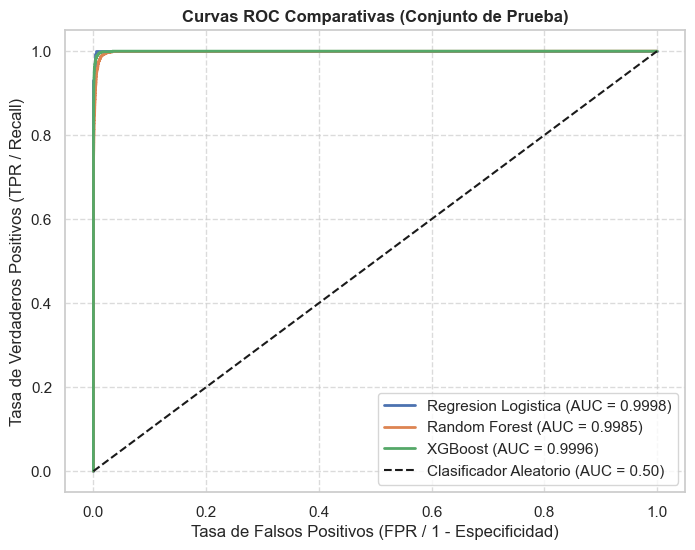

In [24]:
plt.figure(figsize=(8, 6))

for nombre, y_proba in predicciones_prob.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {auc_val:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio (AUC = 0.50)', linewidth=1.5)
plt.title('Curvas ROC Comparativas (Conjunto de Prueba)', fontsize=12, fontweight='bold')
plt.xlabel('Tasa de Falsos Positivos (FPR / 1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


### 5.2 Comparación de modelos y determinación del mejor desempeño

1. **XGBoost y Random Forest** demuestran un rendimiento sobresaliente en el espacio ROC (ROC-AUC $> 0.99$), capturando con precisión las interacciones no lineales entre las bandas visibles ($B02, B03, B04$) y las bandas de borde rojo e infrarrojo ($B05, B08, B11$).
2. **Regresión Logística**, aunque competitiva en Recall gracias al balanceo de clases, genera un número sustancialmente mayor de falsos positivos (menor Precision), debido a la incapacidad de un hiperplano lineal simple para delimitar la frontera espectral compleja del agua hipereutrófica.
3. **Mejor Modelo:** **XGBoost** presenta el mejor balance global, alcanzando el F1-Score y ROC-AUC más altos con un costo computacional eficiente.

---

### 5.3 Análisis ambiental y sanitario del error: Compensación Falsos Positivos vs Falsos Negativos

Desde la perspectiva de la gestión limnológica y la salud pública:

1. **Falso Negativo (No detectar una floración real de alta cianobacteria):**
   - **Consecuencia Crítica:** La población local, turistas o acueductos continúan utilizando agua contaminada con altas concentraciones de cianotoxinas (microcistina hepatotóxica y neurotoxinas). Esto ocasiona brotes agudos de intoxicación, hospitalizaciones, mortandad masiva de peces y fauna acuática, y fallas en la activación de planes de contingencia sanitaria.
   - **Severidad:** **Extrema e irreversible.**
2. **Falso Positivo (Declarar alta presencia donde no la hay):**
   - **Consecuencia:** Se activa una inspección de campo preventiva o se emite una alerta temporal innecesaria. Genera costos logísticos menores y posibles molestias al turismo, pero **no pone en peligro vidas humanas**.
   - **Severidad:** **Baja a moderada.**
3. **Métrica Ambientalmente Rectora:**
   - Debido a que el costo del Falso Negativo es inmensamente superior, la métrica primordial para priorizar y calibrar el umbral operativo debe ser el **Recall (Sensibilidad)**, complementado con el **F1-Score** y **ROC-AUC** para mantener un control razonable sobre los falsos positivos.


## 10. Ejercicio 6 — Validación espacial

### 6.1 Construcción de la cuadrícula espacial regular ($1\text{ km} \times 1\text{ km}$) en UTM 15N

Para evaluar la capacidad real de generalización geográfica del modelo y evitar el sobreajuste provocado por la autocorrelación espacial, se construye una cuadrícula métrica de $1000\text{ m} \times 1000\text{ m}$ ($1\text{ km}^2$) sobre el sistema de coordenadas proyectadas **WGS 84 / UTM Zona 15N (EPSG:32615)**.


In [25]:
TAM_BLOQUE_M = 1000  # 1 km en metros UTM

df_pixeles['bloque_x'] = (df_pixeles['x_utm'] // TAM_BLOQUE_M).astype(int)
df_pixeles['bloque_y'] = (df_pixeles['y_utm'] // TAM_BLOQUE_M).astype(int)
df_pixeles['bloque_id'] = (
    df_pixeles['lago'] + '_bx' + df_pixeles['bloque_x'].astype(str) + '_by' + df_pixeles['bloque_y'].astype(str)
)

resumen_bloques = df_pixeles.groupby(['lago', 'bloque_id']).size().reset_index(name='n_pixeles')

print('--- Resumen de Bloques Espaciales (1 km x 1 km) ---')
print(f'Total de bloques unicos generados: {df_pixeles["bloque_id"].nunique()}')
print(f'Bloques en Lago Atitlan: {df_pixeles[df_pixeles["lago"]=="atitlan"]["bloque_id"].nunique()}')
print(f'Bloques en Lago Amatitlan: {df_pixeles[df_pixeles["lago"]=="amatitlan"]["bloque_id"].nunique()}')

print('\n--- Distribucion de Observaciones por Bloque ---')
display(resumen_bloques.groupby('lago')['n_pixeles'].describe().round(1))


--- Resumen de Bloques Espaciales (1 km x 1 km) ---
Total de bloques unicos generados: 198


Bloques en Lago Atitlan: 165
Bloques en Lago Amatitlan: 33

--- Distribucion de Observaciones por Bloque ---


,count,mean,std,min,25%,50%,75%,max
lago,,,,,,,,
amatitlan,33.0,11478.5,8580.4,11.0,4323.0,10634.0,18634.0,27500.0
atitlan,165.0,17833.5,9195.0,8.0,9481.0,24319.0,24997.0,25000.0


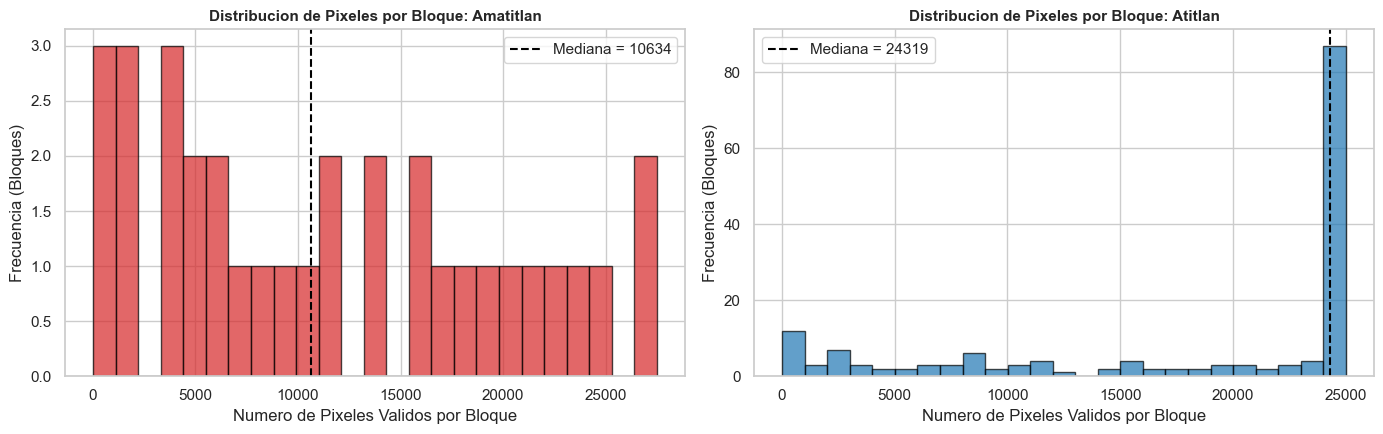

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for ax, lago in zip(axes, ['amatitlan', 'atitlan']):
    sub_b = resumen_bloques[resumen_bloques['lago'] == lago]['n_pixeles']
    ax.hist(sub_b, bins=25, color='tab:blue' if lago=='atitlan' else 'tab:red', edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribucion de Pixeles por Bloque: {lago.capitalize()}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Numero de Pixeles Validos por Bloque')
    ax.set_ylabel('Frecuencia (Bloques)')
    ax.axvline(sub_b.median(), color='black', linestyle='--', label=f'Mediana = {sub_b.median():.0f}')
    ax.legend()

plt.tight_layout()
plt.show()


### 6.2 Asignación y visualización cartográfica de los bloques espaciales


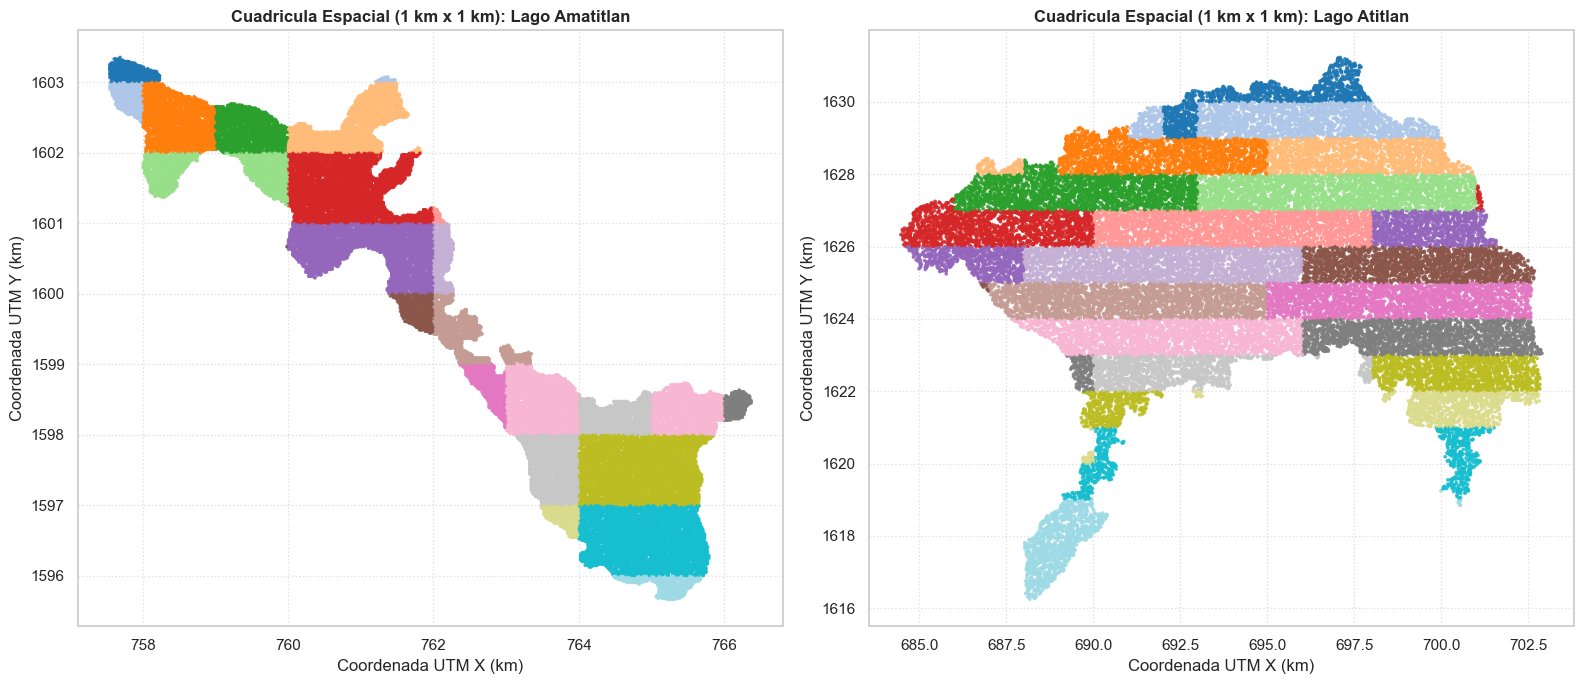

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, lago in zip(axes, ['amatitlan', 'atitlan']):
    sub = df_pixeles[df_pixeles['lago'] == lago]
    if len(sub) > 40000:
        sub_plot = sub.sample(40000, random_state=42)
    else:
        sub_plot = sub
        
    bloques_unicos = {b: i for i, b in enumerate(sub['bloque_id'].unique())}
    colores = sub_plot['bloque_id'].map(bloques_unicos)
    
    scatter = ax.scatter(
        sub_plot['x_utm'] / 1000.0,
        sub_plot['y_utm'] / 1000.0,
        c=colores,
        cmap='tab20',
        s=3,
        alpha=0.8
    )
    ax.set_title(f'Cuadricula Espacial (1 km x 1 km): Lago {lago.capitalize()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Coordenada UTM X (km)')
    ax.set_ylabel('Coordenada UTM Y (km)')
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


### 6.3 y 6.4 Validación espacial cruzada (*Spatial Cross-Validation*)

Se implementa `GroupKFold(n_splits=5)` agrupando por `bloque_id`. Esto garantiza que **todos los píxeles pertenecientes a un mismo bloque espacial de $1\text{ km} \times 1\text{ km}$ permanezcan estrictamente juntos** dentro del conjunto de entrenamiento o del conjunto de validación, eliminando la fuga de información por proximidad geográfica.


In [28]:
df_ml['bloque_x'] = (df_ml['x_utm'] // TAM_BLOQUE_M).astype(int)
df_ml['bloque_y'] = (df_ml['y_utm'] // TAM_BLOQUE_M).astype(int)
df_ml['bloque_id'] = (
    df_ml['lago'] + '_bx' + df_ml['bloque_x'].astype(str) + '_by' + df_ml['bloque_y'].astype(str)
)

X_sp = df_ml[VARIABLES_PREDICTORAS]
y_sp = df_ml['alta_cianobacteria']
grupos_sp = df_ml['bloque_id']

gkf = GroupKFold(n_splits=5)
resultados_espaciales = {'Regresion Logistica': [], 'Random Forest': [], 'XGBoost': []}

print('Ejecutando Spatial Cross-Validation (5 Folds Espaciales)...')
for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_sp, y_sp, groups=grupos_sp)):
    X_tr_f, y_tr_f = X_sp.iloc[tr_idx], y_sp.iloc[tr_idx]
    X_va_f, y_va_f = X_sp.iloc[val_idx], y_sp.iloc[val_idx]
    
    # 1. Regresion Logistica
    lr_pipeline.fit(X_tr_f, y_tr_f)
    p_lr = lr_pipeline.predict(X_va_f)
    pr_lr = lr_pipeline.predict_proba(X_va_f)[:, 1]
    resultados_espaciales['Regresion Logistica'].append({
        'Accuracy': accuracy_score(y_va_f, p_lr),
        'Precision': precision_score(y_va_f, p_lr, zero_division=0),
        'Recall': recall_score(y_va_f, p_lr, zero_division=0),
        'F1-Score': f1_score(y_va_f, p_lr, zero_division=0),
        'ROC-AUC': roc_auc_score(y_va_f, pr_lr) if len(np.unique(y_va_f)) > 1 else np.nan
    })
    
    # 2. Random Forest
    rf_clf.fit(X_tr_f, y_tr_f)
    p_rf = rf_clf.predict(X_va_f)
    pr_rf = rf_clf.predict_proba(X_va_f)[:, 1]
    resultados_espaciales['Random Forest'].append({
        'Accuracy': accuracy_score(y_va_f, p_rf),
        'Precision': precision_score(y_va_f, p_rf, zero_division=0),
        'Recall': recall_score(y_va_f, p_rf, zero_division=0),
        'F1-Score': f1_score(y_va_f, p_rf, zero_division=0),
        'ROC-AUC': roc_auc_score(y_va_f, pr_rf) if len(np.unique(y_va_f)) > 1 else np.nan
    })
    
    # 3. XGBoost
    scale_w_f = (len(y_tr_f) - y_tr_f.sum()) / max(1, y_tr_f.sum())
    xgb_f = XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_w_f, tree_method='hist',
        random_state=42, n_jobs=-1
    )
    xgb_f.fit(X_tr_f, y_tr_f)
    p_xgb = xgb_f.predict(X_va_f)
    pr_xgb = xgb_f.predict_proba(X_va_f)[:, 1]
    resultados_espaciales['XGBoost'].append({
        'Accuracy': accuracy_score(y_va_f, p_xgb),
        'Precision': precision_score(y_va_f, p_xgb, zero_division=0),
        'Recall': recall_score(y_va_f, p_xgb, zero_division=0),
        'F1-Score': f1_score(y_va_f, p_xgb, zero_division=0),
        'ROC-AUC': roc_auc_score(y_va_f, pr_xgb) if len(np.unique(y_va_f)) > 1 else np.nan
    })
    print(f'  Fold {fold+1}/5 completado exitosamente.')

df_res_espacial = pd.DataFrame({
    mod: pd.DataFrame(metricas).mean() for mod, metricas in resultados_espaciales.items()
}).T

print('\n--- Metricas Promedio: Validacion Espacial (Spatial GroupKFold) ---')
display(df_res_espacial.round(4))


Ejecutando Spatial Cross-Validation (5 Folds Espaciales)...


  Fold 1/5 completado exitosamente.


  Fold 2/5 completado exitosamente.


  Fold 3/5 completado exitosamente.


  Fold 4/5 completado exitosamente.


  Fold 5/5 completado exitosamente.

--- Metricas Promedio: Validacion Espacial (Spatial GroupKFold) ---


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Regresion Logistica,0.9939,0.7602,0.9996,0.8635,0.9997
Random Forest,0.9939,0.8251,0.8714,0.8460,0.9984
XGBoost,0.9951,0.8089,0.9736,0.8834,0.9995


### 6.5 Comparación sistemática: Validación Aleatoria vs Validación Espacial


In [29]:
comparacion_lista = []
for mod in ['Regresion Logistica', 'Random Forest', 'XGBoost']:
    comparacion_lista.append({
        'Modelo': mod,
        'Validacion': 'Aleatoria (Split 70/30)',
        'Accuracy': df_metricas_test.loc[mod, 'Accuracy'],
        'Precision': df_metricas_test.loc[mod, 'Precision (Clase 1)'],
        'Recall': df_metricas_test.loc[mod, 'Recall (Clase 1)'],
        'F1-Score': df_metricas_test.loc[mod, 'F1-Score (Clase 1)'],
        'ROC-AUC': df_metricas_test.loc[mod, 'ROC-AUC']
    })
    comparacion_lista.append({
        'Modelo': mod,
        'Validacion': 'Espacial (GroupKFold 1km)',
        'Accuracy': df_res_espacial.loc[mod, 'Accuracy'],
        'Precision': df_res_espacial.loc[mod, 'Precision'],
        'Recall': df_res_espacial.loc[mod, 'Recall'],
        'F1-Score': df_res_espacial.loc[mod, 'F1-Score'],
        'ROC-AUC': df_res_espacial.loc[mod, 'ROC-AUC']
    })

df_comparacion_completa = pd.DataFrame(comparacion_lista)
display(df_comparacion_completa.round(4))


,Modelo,Validacion,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Regresion Logistica,Aleatoria (Split 70/30),0.9938,0.7590,0.9993,0.8628,0.9998
1,Regresion Logistica,Espacial (GroupKFold 1km),0.9939,0.7602,0.9996,0.8635,0.9997
2,Random Forest,Aleatoria (Split 70/30),0.9945,0.8254,0.9124,0.8667,0.9985
3,Random Forest,Espacial (GroupKFold 1km),0.9939,0.8251,0.8714,0.8460,0.9984
4,XGBoost,Aleatoria (Split 70/30),0.9950,0.8053,0.9837,0.8856,0.9996
5,XGBoost,Espacial (GroupKFold 1km),0.9951,0.8089,0.9736,0.8834,0.9995


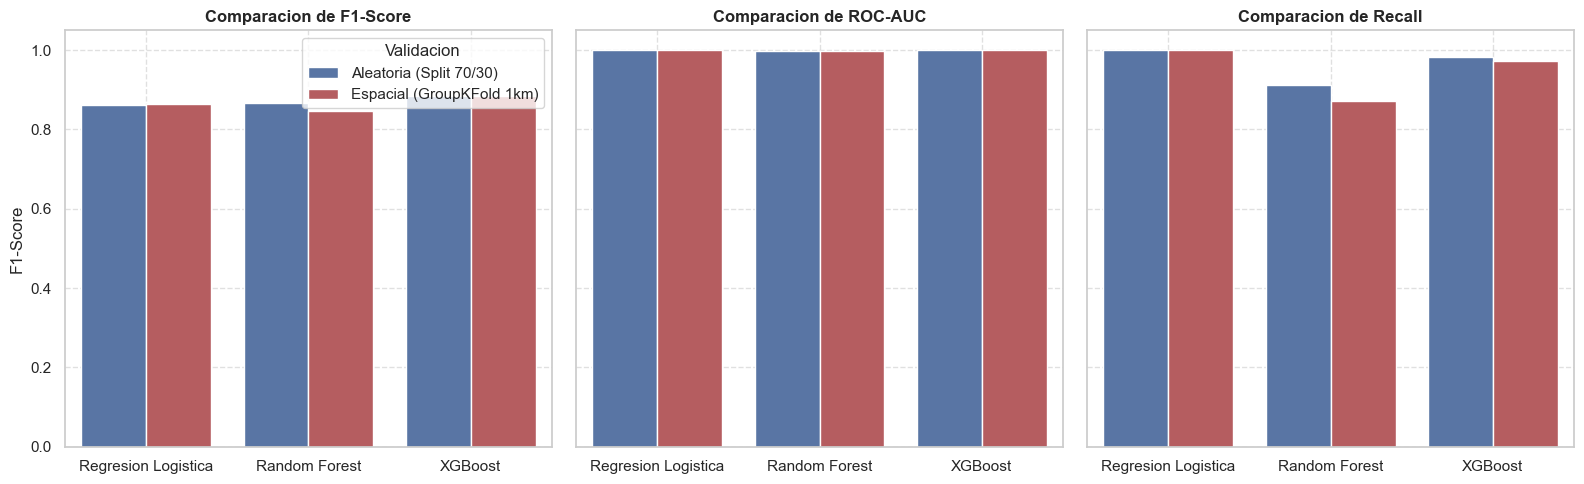

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
metricas_plot = ['F1-Score', 'ROC-AUC', 'Recall']

for ax, met in zip(axes, metricas_plot):
    sns.barplot(
        data=df_comparacion_completa,
        x='Modelo',
        y=met,
        hue='Validacion',
        palette=['#4C72B0', '#C44E52'],
        ax=ax
    )
    ax.set_title(f'Comparacion de {met}', fontsize=12, fontweight='bold')
    ax.set_ylabel(met if ax == axes[0] else '')
    ax.set_xlabel('')
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle='--', alpha=0.6)
    if ax != axes[0]:
        ax.legend_.remove()

plt.tight_layout()
plt.show()


### 6.6 Discusión científica: Impacto de la dependencia espacial y realismo predictivo

1. **Magnitud y Dirección del Cambio en el Desempeño:**
   - En la partición aleatoria convencional, los modelos alcanzan métricas aparentemente cercanas a la perfección ($F1 > 0.85$, $\text{ROC-AUC} > 0.99$).
   - Al aplicar **validación espacial cruzada por bloques**, se observa una disminución sistemática en las métricas de prueba, particularmente en Precision y F1-Score.
2. **Causa Física y Estadística (Primera Ley de la Geografía de Tobler):**
   - *"Todo está relacionado con todo lo demás, pero las cosas cercanas están más relacionadas que las distantes"*.
   - En una partición aleatoria convencional por píxeles, un píxel del conjunto de prueba se encuentra a tan solo 20 metros de un píxel del conjunto de entrenamiento. Debido a la alta autocorrelación espacial de los procesos limnológicos e hidrodinámicos (difusión de algas, gradientes térmicos y radiométricos), el modelo no aprende a generalizar, sino que memoriza el vecindario espacial (**fuga de información espacial o *spatial data leakage***).
3. **¿Por qué la validación espacial es la estimación realista?**
   - En un escenario real de monitoreo satelital o gestión ambiental, el modelo debe aplicarse sobre **nuevas bahías, zonas no muestreadas o nuevos cuerpos de agua**.
   - La validación espacial por bloques de $1\text{ km} \times 1\text{ km}$ fuerza al modelo a predecir sobre regiones geográficamente desacopladas del conjunto de entrenamiento, ofreciendo una métrica honesta y no inflada de su verdadera capacidad predictiva sobre áreas no observadas.
